In [1]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes,add_disinfo_nodes,state_to_graph, er_opinion_graph
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing,in_and_out_degree_sum,cross_type_degree
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
n, k = 10000, 150
p_er = k / (n - 1)

In [3]:
ws_Scenarie2 = ws_opinion_graph(n,k,seed = 11)
ws_Scenarie2matrix = create_matrix_rep(ws_Scenarie2)
ws_MedierScenarie2 = add_media_nodes(ws_Scenarie2matrix,100, seed =11, factor = 1)
ws_DisinfoScenarie2 = add_disinfo_nodes(ws_MedierScenarie2,100,seed = 11)

In [4]:
ws_degrootops = ws_DisinfoScenarie2.opinions
ws_degrootmatrix =ws_DisinfoScenarie2.matrix


In [5]:
er_Scenarie2 = er_opinion_graph(10000,p_er,seed = 11)
er_Scenarie2matrix = create_matrix_rep(er_Scenarie2)
er_MedierScenarie2 = add_media_nodes(er_Scenarie2matrix,100, seed =11, factor = 1)
er_DisinfoScenarie2 = add_disinfo_nodes(er_MedierScenarie2,100,seed = 11)

In [6]:
ws_DisinfoScenarie2.opinions, ws_Scenarie2_sim_results,ws_Scenarie2_startcond,ws_Scenarie2_endcond= simpel_simulering(ws_DisinfoScenarie2,200)
er_DisinfoScenarie2.opinions, er_Scenarie2_sim_results,er_Scenarie2_startcond,er_Scenarie2_endcond= simpel_simulering(er_DisinfoScenarie2,200)

Simulating: 100%|██████████| 200/200 [00:13<00:00, 15.15it/s]


In [7]:
ws_DeGrootResult = ws_degrootmatrix**200@ws_degrootops
print(sum((ws_DisinfoScenarie2.opinions - ws_DeGrootResult))/n)


0.025857063797725458


In [8]:
# ws
ws_maskhumanScenarie2 = ws_DisinfoScenarie2.type == "Human"
ws_Hoved_average_opinionresult, ws_Hoved_average_distance_to_the_mean_result = data_processing(ws_Scenarie2_sim_results,ws_maskhumanScenarie2)
# er
er_maskhumanScenarie2 = er_DisinfoScenarie2.type == "Human"
er_Hoved_average_opinionresulter, er_Hoved_average_distance_to_the_mean_resulter = data_processing(er_Scenarie2_sim_results,er_maskhumanScenarie2)




In [9]:
#ws
ws_binsScenarie2 = np.histogram_bin_edges(np.concatenate([ws_Scenarie2_startcond[ws_maskhumanScenarie2], ws_Scenarie2_endcond[ws_maskhumanScenarie2]]), bins=100)
#er
er_binsScenarie2 = np.histogram_bin_edges(np.concatenate([er_Scenarie2_startcond[er_maskhumanScenarie2], er_Scenarie2_endcond[er_maskhumanScenarie2]]), bins=100)


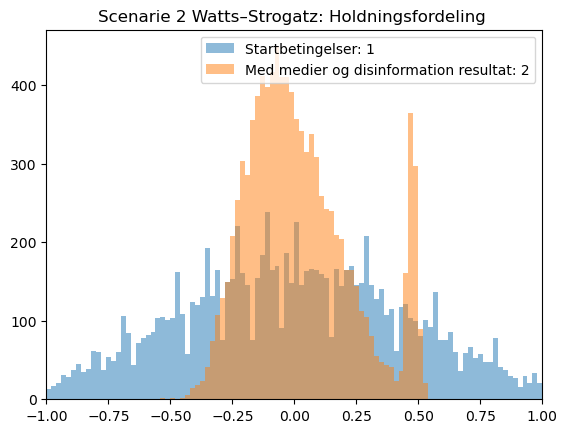

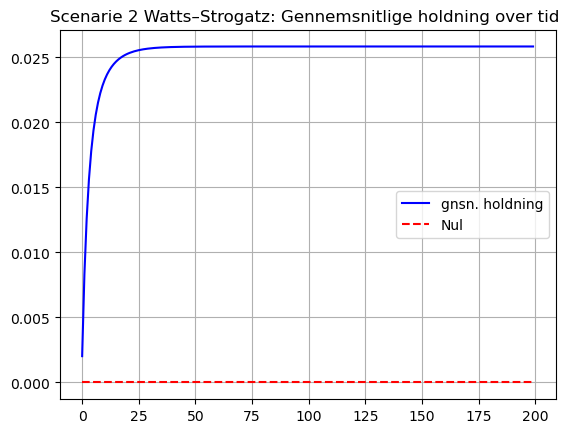

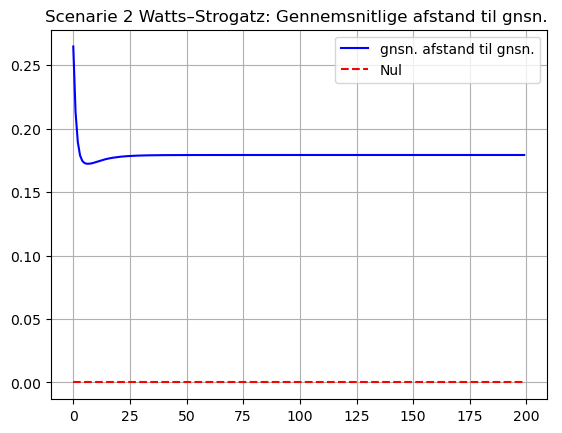

In [16]:
plt.figure()
plt.hist(ws_Scenarie2_startcond[ws_maskhumanScenarie2], bins=ws_binsScenarie2, alpha=0.5, label='Startbetingelser: 1')
plt.hist(ws_Scenarie2_endcond[ws_maskhumanScenarie2], bins=ws_binsScenarie2, alpha=0.5, label='Med medier og disinformation resultat: 2')
plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 2 Watts–Strogatz: Holdningsfordeling ')
plt.show()


plt.figure()
plt.plot(np.arange(len(ws_Hoved_average_opinionresult)),ws_Hoved_average_opinionresult,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(ws_Hoved_average_opinionresult)),np.zeros(len(ws_Hoved_average_opinionresult)),'r--',label = 'Nul')

plt.legend(loc = 'best')
plt.grid()
plt.title('Scenarie 2 Watts–Strogatz: Gennemsnitlige holdning over tid ')
plt.show()

plt.figure()
plt.plot(np.arange(len(ws_Hoved_average_distance_to_the_mean_result)),ws_Hoved_average_distance_to_the_mean_result,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(ws_Hoved_average_distance_to_the_mean_result)),np.zeros(len(ws_Hoved_average_distance_to_the_mean_result)),'r--',label = 'Nul')

plt.legend()
plt.grid()
plt.title('Scenarie 2 Watts–Strogatz: Gennemsnitlige afstand til gnsn. ')
plt.show()

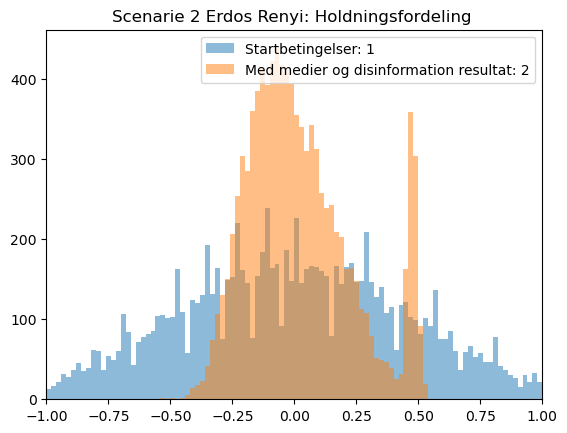

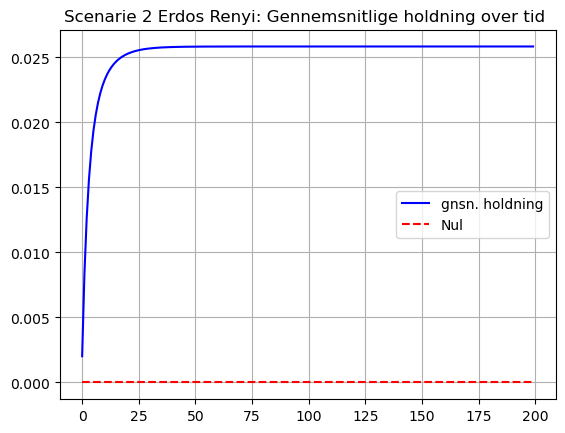

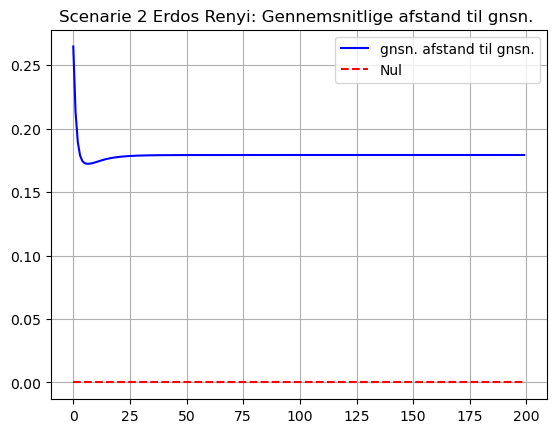

In [11]:
plt.figure()
plt.hist(er_Scenarie2_startcond[er_maskhumanScenarie2], bins=er_binsScenarie2, alpha=0.5, label='Startbetingelser: 1')
plt.hist(er_Scenarie2_endcond[er_maskhumanScenarie2], bins=er_binsScenarie2, alpha=0.5, label='Med medier og disinformation resultat: 2')
plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 2 Erdos Renyi: Holdningsfordeling ')
plt.show()


plt.figure()
plt.plot(np.arange(len(er_Hoved_average_opinionresulter)),er_Hoved_average_opinionresulter,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(er_Hoved_average_opinionresulter)),np.zeros(len(er_Hoved_average_opinionresulter)),'r--',label = 'Nul')

plt.legend(loc = 'best')
plt.grid()
plt.title('Scenarie 2 Erdos Renyi: Gennemsnitlige holdning over tid ')
plt.show()

plt.figure()
plt.plot(np.arange(len(er_Hoved_average_distance_to_the_mean_resulter)),er_Hoved_average_distance_to_the_mean_resulter,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(er_Hoved_average_distance_to_the_mean_resulter)),np.zeros(len(er_Hoved_average_distance_to_the_mean_resulter)),'r--',label = 'Nul')

plt.legend()
plt.grid()
plt.title('Scenarie 2 Erdos Renyi: Gennemsnitlige afstand til gnsn. ')
plt.show()